# How many standard deviations above or below the mean is a specific university's 10-year median salary?(MIT & UCB)

This is an Census study, as we have accsess to the data from all of the schools in the us, or in otherwords the entire population. we can then compare the mean 10 year salary from all graduates to find a global average. from this we can see what schools stick out or have the highest z score.

In [5]:
import pandas as pd
df = pd.read_csv("cleaned_college.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6273 entries, 0 to 6272
Columns: 124 entries, school_id to main_degree
dtypes: float64(110), int64(8), str(6)
memory usage: 6.4 MB


--- Z-SCORE SCALE (-10 to +10) ---
Z = -10 : $-127,528.80
Z =  -9 : $-110,396.52
Z =  -8 : $ -93,264.24
Z =  -7 : $ -76,131.97
Z =  -6 : $ -58,999.69
Z =  -5 : $ -41,867.41
Z =  -4 : $ -24,735.13
Z =  -3 : $  -7,602.86
Z =  -2 : $   9,529.42
Z =  -1 : $  26,661.70
Z =  +0 : $  43,793.97
Z =  +1 : $  60,926.25
Z =  +2 : $  78,058.53
Z =  +3 : $  95,190.81
Z =  +4 : $ 112,323.08
Z =  +5 : $ 129,455.36
Z =  +6 : $ 146,587.64
Z =  +7 : $ 163,719.91
Z =  +8 : $ 180,852.19
Z =  +9 : $ 197,984.47
Z = +10 : $ 215,116.75
-----------------------------------
Average Earnings (Mean) : $43,793.97
Standard Deviation      : $17,132.28
MIT  | Earnings: $143,372.00 | Z-Score: +5.81
UCB  | Earnings: $92,446.00 | Z-Score: +2.84
-----------------------------------


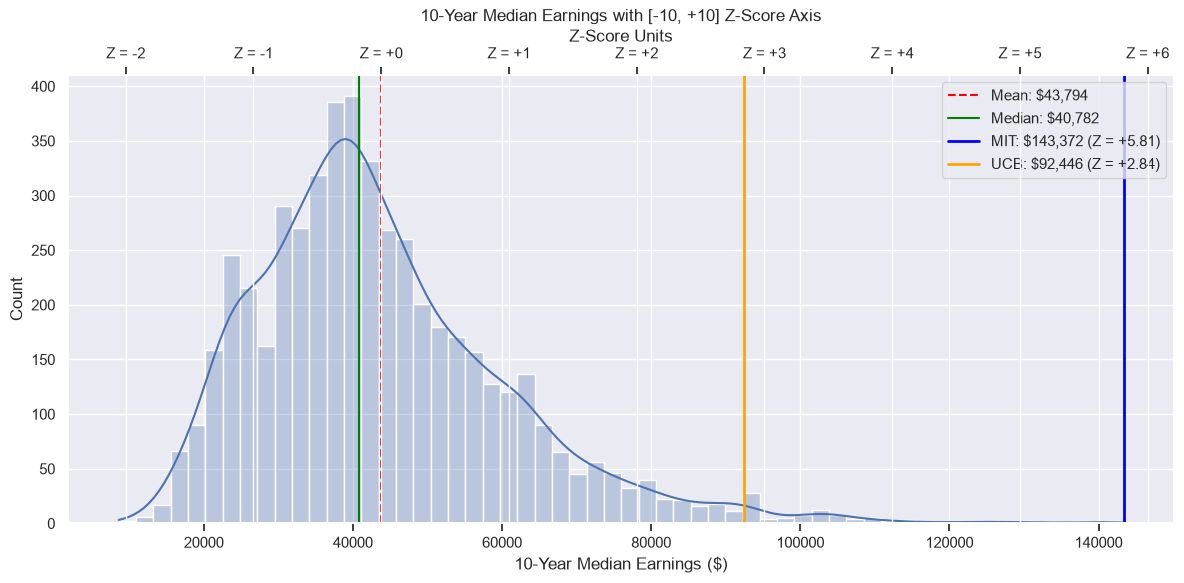

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("cleaned_college.csv")
sns.set_theme()

# Filter UCB and MIT
MIT = df[
    df["school_name"].str.contains(
        "Massachusetts Institute of Technology", case=False
    )
].copy()
UCB = df[
    df["school_name"].str.contains(
        "University of California-Berkeley", case=False
    )
].copy()

# Extract earnings values as scalars
mit_val = MIT["median_earnings_10yrs"].iloc[0]
ucb_val = UCB["median_earnings_10yrs"].iloc[0]

# Summary Statistics
mean_val = df["median_earnings_10yrs"].mean()
median_val = df["median_earnings_10yrs"].median()
std_val = df["median_earnings_10yrs"].std()

# De-fragment DataFrame memory layout
df = df.copy()

# Calculate Z-scores
df["z_score"] = (df["median_earnings_10yrs"] - mean_val) / std_val
mit_z = (mit_val - mean_val) / std_val
ucb_z = (ucb_val - mean_val) / std_val

# ----------------------------------------------------
# Print Scale Reference (-10 to +10)
# ----------------------------------------------------
print("--- Z-SCORE SCALE (-10 to +10) ---")
for z in range(-10, 11):
    val = mean_val + (z * std_val)
    print(f"Z = {z:+3d} : ${val:11,.2f}")
print("-" * 35)
print(f"Average Earnings (Mean) : ${mean_val:,.2f}")
print(f"Standard Deviation      : ${std_val:,.2f}")
print(f"MIT  | Earnings: ${mit_val:,.2f} | Z-Score: {mit_z:+.2f}")
print(f"UCB  | Earnings: ${ucb_val:,.2f} | Z-Score: {ucb_z:+.2f}")
print("-" * 35)

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=df,
    x="median_earnings_10yrs",
    kde=True,
    alpha=0.3,
    ax=ax1,
)

# Reference lines
ax1.axvline(
    mean_val, color="red", linestyle="--", label=f"Mean: ${mean_val:,.0f}"
)
ax1.axvline(
    median_val,
    color="green",
    linestyle="-",
    label=f"Median: ${median_val:,.0f}",
)

# Highlight MIT and UCB
ax1.axvline(
    mit_val,
    color="blue",
    linewidth=2,
    linestyle="-",
    label=f"MIT: ${mit_val:,.0f} (Z = {mit_z:+.2f})",
)
ax1.axvline(
    ucb_val,
    color="orange",
    linewidth=2,
    linestyle="-",
    label=f"UCB: ${ucb_val:,.0f} (Z = {ucb_z:+.2f})",
)

ax1.set_title("10-Year Median Earnings with [-10, +10] Z-Score Axis")
ax1.set_xlabel("10-Year Median Earnings ($)")
ax1.set_ylabel("Count")
ax1.legend(loc="upper right")

# Add a secondary top x-axis for Z-Scores ranging from -10 to +10
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())

# Generate all Z-score values from -10 to +10
z_scale = list(range(-10, 11))
dollar_scale = [mean_val + z * std_val for z in z_scale]

# Filter tick locations so only those within the current x-axis view range are displayed
xmin, xmax = ax1.get_xlim()
valid_ticks = [
    (z, d) for z, d in zip(z_scale, dollar_scale) if xmin <= d <= xmax
]

if valid_ticks:
    z_ticks_visible, dollar_ticks_visible = zip(*valid_ticks)
    ax2.set_xticks(dollar_ticks_visible)
    ax2.set_xticklabels([f"Z = {z:+d}" for z in z_ticks_visible])

ax2.set_xlabel("Z-Score Units")

plt.tight_layout()
plt.show()

In [68]:
import difflib
import pandas as pd

df = pd.read_csv("cleaned_college.csv")

# 1. Summary statistics for median earnings
mean_val = df["median_earnings_10yrs"].mean()
std_val = df["median_earnings_10yrs"].std()

# 2. Ask for input
school_query = input("Enter a school name: ")

# 3. Step A: Try direct substring match first
substring_matches = df[
    df["school_name"].str.contains(school_query, case=False, na=False)
]

if not substring_matches.empty:
    school = substring_matches.iloc[0]
else:
    # Step B: Fall back to closest match if substring fails (handles typos)
    all_schools = df["school_name"].dropna().unique()
    closest_matches = difflib.get_close_matches(
        school_query, all_schools, n=1, cutoff=0.3
    )

    if closest_matches:
        matched_name = closest_matches[0]
        school = df[df["school_name"] == matched_name].iloc[0]
    else:
        school = None

# 4. Output results
if school is None:
    print("No school found.")
else:
    income_val = school["median_earnings_10yrs"]
    z_score = (income_val - mean_val) / std_val

    print(f"\nMatched School: {school['school_name']}")
    print(f"Income Value: ${income_val:,.2f}")
    print(f"Standard Value (Std Dev): ${std_val:,.2f}")
    print(f"Z-Score: {z_score:+.2f}")

Enter a school name:  high point



Matched School: High Point University
Income Value: $61,389.00
Standard Value (Std Dev): $17,132.28
Z-Score: +1.03


# conclusion 
The dataset shows a right-skewed (positively skewed) distribution of 10-year median earnings, peaking around 38,000 to 40,000 near the overall median of 40,782.   Because a high concentration of schools earn below the mean of 43,794, most schools actually sit at a negative z-score between Z = -1 and Z = 0. Extreme high-earning outliers pull the overall average up.   For instance, UC Berkeley (Z = +2.84, 92,446) sits nearly 3 standard deviations above average, while MIT (Z = +5.81, 143,372) sits nearly 6 standard deviations above average—earning over 3.2 times the overall mean. 